In [29]:
import numpy as np
import matplotlib.pyplot as plt
import os
from os import path
import json
import textwrap
import sys
sys.path.insert(0, "/home/thomasb/")

# Baseband utils script
from albatros_analysis.src.utils import baseband_utils as butils

In [9]:
#data paths
# ant_paths_all = np.array([
#     '/project/rrg-sievers/albatros/mars/202507/mars1/baseband',
#     '/project/rrg-sievers/albatros/mars/202507/mars2/baseband',
#     '/project/rrg-sievers/albatros/mars/202507/mars3/baseband',
#     '/project/rrg-sievers/albatros/mars/202507/mars4/baseband',
#     '/project/rrg-sievers/albatros/mars/202507/mars5/baseband',
#     '/project/rrg-sievers/albatros/mars/202507/mars6/baseband',
#     '/project/rrg-sievers/albatros/mars/202507/mars7/baseband',
#     '/project/rrg-sievers/albatros/mars/202507/mars8/baseband'
# ])

ant_paths_all = [
    "/scratch/mohanagr/drive3_mars_spring2025/baseband",
    "/scratch/mohanagr/drive2_mars_spring2025/baseband"
]

ant_coords_all = [
    [79.41716147, -90.76723869, 187.9577], #mars1
    [79.41719805, -90.75873919, 183.0684]  #mars2
]

ant_names_all = [
    "MARS1",
    "MARS2",
    #"MARS3",
    #"MARS4",
    #"MARS5",
    #"MARS6",
    #"MARS7",
    #"MARS8"
    ]

## 1. Choosing Where to Look
First we have to decide what antenna we want to look at, what time interval we care about, and what the time resolution is on our data search (a typical choice is 5 seconds)

In [3]:
#interval_start, interval_end = 1761980000, 1762500000
interval_start, interval_end = 1746782095 - 100000, 1746782095 +100000
T_SCAN = 5
#desired_ant_idxs = [0, 1, 3, 4]
desired_ant_idxs = [0, 1]

ant_paths = ant_paths_all[desired_ant_idxs]
ant_names = ant_names_all[desired_ant_idxs]

print(ant_names)
print(ant_paths)

['MARS1' 'MARS2']
['/scratch/mohanagr/drive3_mars_spring2025/baseband'
 '/scratch/mohanagr/drive2_mars_spring2025/baseband']


## 2. Binary File Presence
Next, we can determine an array of binary file presence or absence for all our desired antenna, for our entire interval.

1746682025 1746882095
1746682025 1746882095


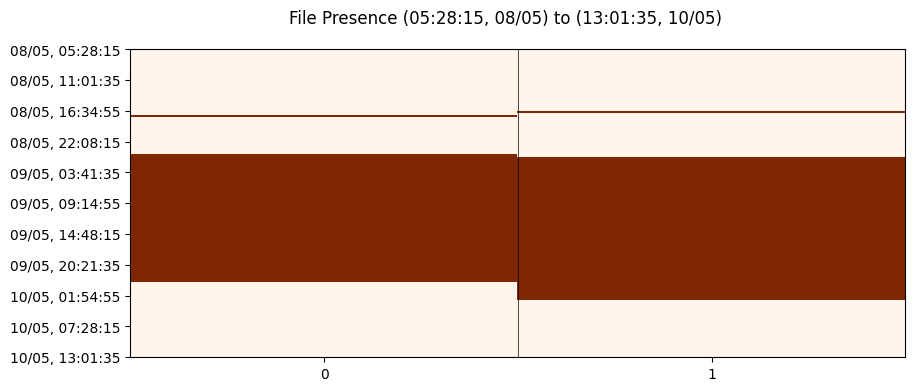

In [4]:
#determine file presence (get big array)
arr, fig = butils.get_present_files(interval_start, interval_end, ant_paths, T_SCAN = T_SCAN)

Take closer look

1746732025 1746862095
1746732025 1746862095


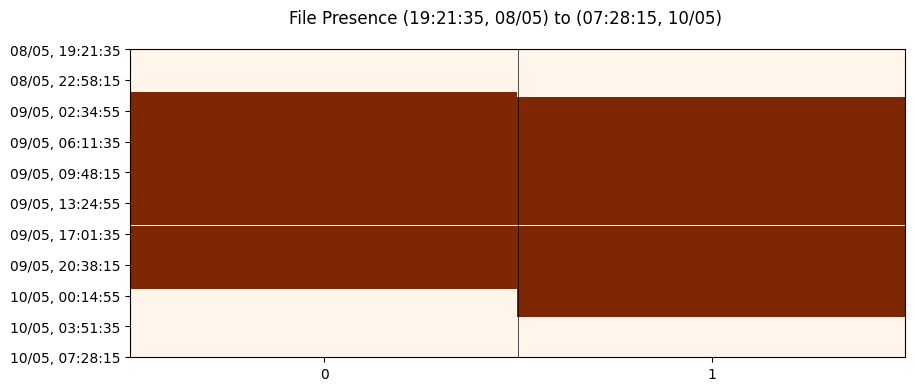

In [18]:
_ , _ = butils.get_present_files(interval_start + 50000, interval_end-20000, ant_paths, T_SCAN = T_SCAN)

## 3. Continuous Data Presence (A Batch)
Finally, we can determine all the contiguous stretches of data. We can select a different set of antenna indices (a subset of our first desired_ant_idxs selection) if we see that some antenna are particularly bad/patchy.

In [10]:
#if you want to include all antenna
#idxs2 = np.arange(len(desired_ant_idxs))

#if you want to exclude MARS 1 since it's ratty as hell
idxs2 = [0, 1]

runs = butils.get_simul_files(arr, interval_start, T_SCAN, idxs2)
for i, r in enumerate(runs):
    print(f'batch {i}', r, 'dt:', r[1]-r[0])

batch 0 [1746752235, 1746806450] dt: 54215
batch 1 [1746806655, 1746833570] dt: 26915


In [19]:
#select which batches we want...
subdir = 'satdet_spring'

Make config files and full job scripts for each 'good' batch

In [22]:
path_orbcomm="/home/thomasb/albatros_analysis/scripts/orbcomm"
ref_ant="MARS1"
secondary_ant="MARS2"

In [31]:
for r in runs:
    file = {}
    antennas = {}
    nant = len(ant_names_all)

    for j in range(nant):
        antennas[ant_names_all[j]] = {}
        antennas[ant_names_all[j]]["name"] = ant_names_all[j]
        antennas[ant_names_all[j]]["path"] = ant_paths_all[j]
        antennas[ant_names_all[j]]["coordinates"] = list(ant_coords_all[j])

    file['antennas'] = antennas

    file["correlation"] = {
        "start_timestamp": r[0],
        "end_timestamp": r[1],
        "coarse_acclen": 3000000,
        "osamp": 64,
        "pfb_size": 65536,
        "new_acclen": 1024
    }

    file["frequency"] = {
        "start_channel": 1834,
        "end_channel": 1852
    }

    path_config = f'/home/thomasb/albatros_analysis/scripts/orbcomm/config/{subdir}/batch_{r[0]}.json'
    with open(path_config, "w") as f:
            json.dump(file, f, indent=4)




    job_name = f'full_job_{r[0]}'
    path_batch = f'/scratch/thomasb/batch{r[0]}'

    script = textwrap.dedent(f"""\
    #!/bin/bash
    #SBATCH --job-name={job_name}
    #SBATCH --output=/scratch/thomasb/{job_name}_%j.out
    #SBATCH --nodes=1
    #SBATCH --gpus-per-node=1
    #SBATCH --time=20:00:00

    batch_start_ts={r[0]}
    path_batch="/scratch/thomasb/batch_${{batch_start_ts}}"
    path_orbcomm="/home/thomasb/albatros_analysis/scripts/orbcomm"
    path_config="${{path_orbcomm}}/config/config_batch2.json"
    ref_ant="{ref_ant}"
    secondary_ant="{secondary_ant}"

    # setup
    source /home/thomasb/albatros_analysis/src/setup_gpu.sh
    srun nvidia-smi

    # satdet
    srun python "${{path_orbcomm}}/get_satdet.py" "${{path_config}}"

    # consensus offsets
    srun python "${{path_orbcomm}}/get_consensus_offsets.py" "${{batch_start_ts}}" -ref "${{ref_ant}}" -f

    # pulse list
    srun python "${{path_orbcomm}}/get_pulse_list.py" "${{path_config}}" -ref "${{ref_ant}}" -sec "${{secondary_ant}}"

    # UTC discrepancies
    srun python "${{path_orbcomm}}/get_batch_discrepancies.py" "${{path_config}}" -m

    # map fit
    srun python "${{path_orbcomm}}/get_UTC_map.py" "${{batch_start_ts}}"

    # fine timing
    srun python "${{path_orbcomm}}/get_batch_finetiming.py" "${{path_config}}" -m
    """)

    with open(f"/home/thomasb/albatros_analysis/scripts/orbcomm/jobs/{job_name}.sh", "w") as f:
        f.write(script)